In [ ]:
# RUN THIS CELL FIRST
# This fixes the Keras 3/ Transformers compatibility issue
print("Installing Keras 2...")
!pip install tf_keras -q
print("Setting environment variable to use Keras 2...")
import os
os.environ['TF_USE_LEGACY_KERAS'] = 'True'
print("Done! Please restart the runtime.")

Installing Keras 2...
Setting environment variable to use Keras 2...
Done! Please restart the runtime.


In [ ]:
# Install the necessary libraries
!pip install transformers datasets -q

# Import libraries
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Load the IMDB dataset from Hugging Face
print("Loading IMDB dataset...")
imdb_dataset = load_dataset("imdb")

print("\nDataset structure:")
print(imdb_dataset)

print("\nExample from training set:")
print(imdb_dataset["train"][0])

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example from training set:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the 

In [ ]:
# Define the model checkpoint
MODEL_NAME = "roberta-base"  # <-- UPDATED FROM DISTILBERT

# Load the tokenizer
print(f"Loading tokenizer for '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")

Loading tokenizer for 'roberta-base'...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded.


In [ ]:
# Preprocessing & Tokenization
def tokenize_function(examples):
  # Truncate=True: Cut off reviews that are too long
  # Padding="max_length": Add padding to reviews that are too short
  # max_length=256: A good balance for review length
  return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)

print("Tokenizing the dataset (this may take a minute)...")
# .map() applies the function to the entire dataset efficiently
tokenized_datasets = imdb_dataset.map(tokenize_function, batched=True)
print("Tokenization complete.")

print("\nExample of a tokenized review:")
print(tokenized_datasets["train"][0])

Tokenizing the dataset (this may take a minute)...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenization complete.

Example of a tokenized review:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographi

In [ ]:
# Set batch size
BATCH_SIZE = 16

print("Converting datasets to tf.data.Dataset format...")

# Convert the training set
tf_train_dataset = tokenized_datasets["train"].to_tf_dataset(
    # THIS IS THE FIX
    # Remove "label" from this list
    columns=["attention_mask", "input_ids"],
    # END OF FIX ---
    label_cols=["label"],
    shuffle=True,
    batch_size=BATCH_SIZE
)

# Convert the testing set
tf_test_dataset = tokenized_datasets["test"].to_tf_dataset(
    # THIS IS THE FIX
    # Remove "label" from this list
    columns=["attention_mask", "input_ids"],
    # END OF FIX
    label_cols=["label"],
    shuffle=False,
    batch_size=BATCH_SIZE
)

# We'll also grab the test labels for our confusion matrix later
y_test = np.array(tokenized_datasets["test"]["label"])

print("Conversion complete.")

Converting datasets to tf.data.Dataset format...


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


Conversion complete.


In [ ]:
print(f"Loading pre-trained model '{MODEL_NAME}'...")
# Load the model, specifying 2 labels (positive/negative)
model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    use_safetensors=False # Keep this fix from before
)

#
# Compile the model
#
# THIS IS THE FIX ---
# We must use the 'legacy' Adam optimizer for compatibility
# with the transformers library and Keras 3.
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=2e-5) # <-- UPDATED LEARNING RATE
# END OF FIX

# The model outputs "logits" (raw scores), so we use from_logits=True
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer, # Pass the legacy optimizer object
    loss=loss,
    metrics=["accuracy"]
)

print("Model loaded and compiled.")
model.summary()

Loading pre-trained model 'roberta-base'...


Transformers is only compatible with Keras 2, but you have explicitly set `TF_USE_LEGACY_KERAS` to `0`. This may result in unexpected behaviour or errors if Keras 3 objects are passed to Transformers models.


tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

Some layers of TFRobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and compiled.
Model: "tf_roberta_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 roberta (TFRobertaMainLaye  multiple                  124055040 
 r)                                                              
                                                                 
 classifier (TFRobertaClass  multiple                  592130    
 ificationHead)                                                  
                                                                 
Total params: 124647170 (475.49 MB)
Trainable params: 124647170 (475.49 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Import the EarlyStopping callback
from tf_keras.src.callbacks import EarlyStopping

NUM_EPOCHS = 3 # We can leave this at 3

# ADD THIS ---
# Create an EarlyStopping callback
# 1. monitor='val_loss': Watch the validation loss
# 2. patience=1: Stop if val_loss doesn't improve for 1 full epoch
# 3. restore_best_weights=True: THIS IS KEY. It will automatically give
#    you back the model from the best epoch.
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)
# END ADDITION

print("Starting model training with Early Stopping...")
history = model.fit(
    tf_train_dataset,
    validation_data=tf_test_dataset,
    epochs=NUM_EPOCHS,
    # ADD THIS
    callbacks=[early_stopping_cb] # Pass the callback here
    # END ADDITION
)

print("Model training complete!")

Starting model training with Early Stopping...
Epoch 1/3
1563/1563 [==============================] - 1901s 1s/step - loss: 0.2303 - accuracy: 0.9078 - val_loss: 0.1854 - val_accuracy: 0.9317
Epoch 2/3
1563/1563 [==============================] - 1878s 1s/step - loss: 0.1424 - accuracy: 0.9468 - val_loss: 0.1797 - val_accuracy: 0.9361
Epoch 3/3
1563/1563 [==============================] - 1877s 1s/step - loss: 0.0986 - accuracy: 0.9659 - val_loss: 0.1727 - val_accuracy: 0.9348
Model training complete!


In [ ]:
from google.colab import drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# Define the save path inside your Google Drive
# You can change 'my_roberta_model' to any folder name you want
save_path = "/content/drive/MyDrive/my_roberta_model" # <-- UPDATED SAVE PATH

print(f"Saving model to Google Drive at: {save_path}")
model.save_pretrained(save_path)

# We must also save the tokenizer
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully to your Google Drive!")

Connecting to Google Drive...
Mounted at /content/drive
Saving model to Google Drive at: /content/drive/MyDrive/my_roberta_model
Model and tokenizer saved successfully to your Google Drive!


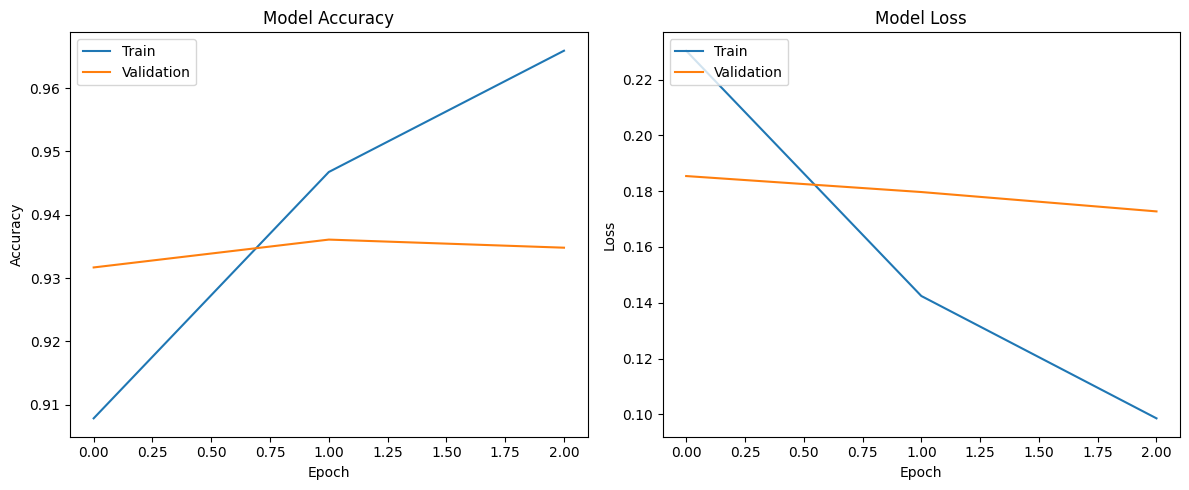

In [ ]:
def plot_history(history):
  # Plot training & validation accuracy values
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  # Plot training & validation loss values
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  plt.tight_layout()
  plt.show()

plot_history(history)

Evaluating model on test set...
1563/1563 [==============================] - 477s 305ms/step - loss: 0.1727 - accuracy: 0.9348
Test Accuracy: 93.48%
Test Loss: 0.1727


1563/1563 [==============================] - 471s 300ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94     12500
    Positive       0.94      0.93      0.93     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000





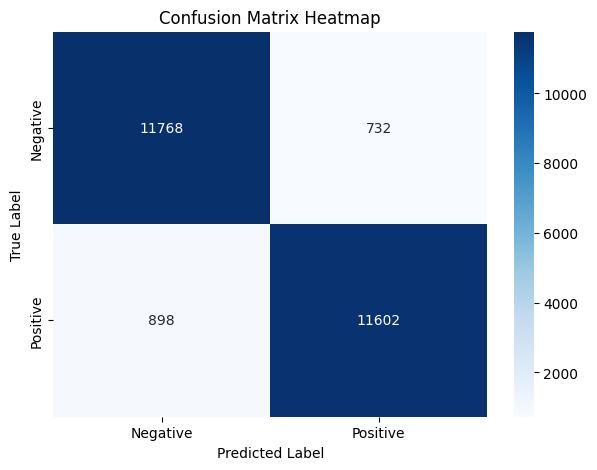

In [ ]:
print("Evaluating model on test set...")
# 1. Evaluate on test data
loss, accuracy = model.evaluate(tf_test_dataset)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

print("\n" + "="*50 + "\n")

# 2. Get predictions for the whole test set
# This will take a moment
raw_predictions = model.predict(tf_test_dataset)

# The model outputs logits, so we use argmax to get the predicted class (0 or 1)
y_pred = np.argmax(raw_predictions.logits, axis=1)

# 3. Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

print("\n" + "="*50 + "\n")

# 4. Generate and Plot Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generating word clouds...


Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

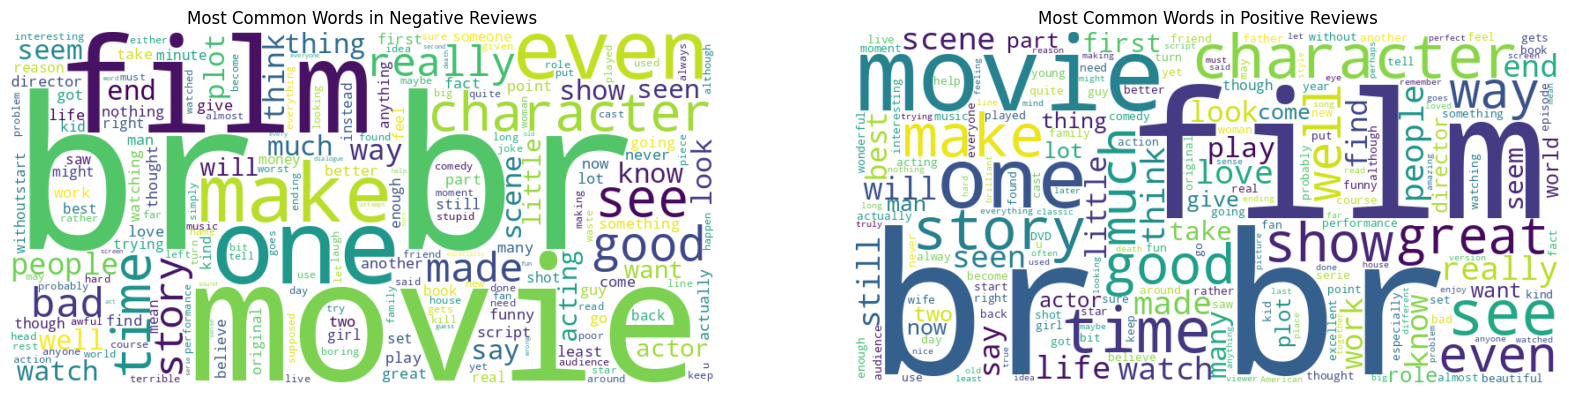

In [ ]:
# FIX: Install and import the wordcloud library
!pip install wordcloud -q
from wordcloud import WordCloud

# We need to re-create the text lists from the Hugging Face dataset
print("Generating word clouds...")
negative_reviews = " ".join(imdb_dataset['train'].filter(lambda x: x['label'] == 0)['text'])
positive_reviews = " ".join(imdb_dataset['train'].filter(lambda x: x['label'] == 1)['text'])

# Create Word Clouds
wc_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
wc_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

# Plot the word clouds
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wc_negative, interpolation='bilinear')
plt.title('Most Common Words in Negative Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_positive, interpolation='bilinear')
plt.title('Most Common Words in Positive Reviews')
plt.axis('off')

plt.show()

In [ ]:
def predict_sentiment(review_text):
  # 1. Tokenize the text
  # return_tensors="tf" tells the tokenizer to output TensorFlow tensors
  inputs = tokenizer(review_text, return_tensors="tf", truncation=True, padding=True)

  # 2. Make a prediction
  raw_outputs = model.predict(dict(inputs))

  # 3. Get the logits (raw scores)
  logits = raw_outputs.logits[0]

  # 4. Convert logits to probabilities using softmax
  probabilities = tf.nn.softmax(logits).numpy()

  # 5. Get the predicted class (0 or 1)
  prediction = np.argmax(probabilities)

  if prediction == 1:
    sentiment = "Positive"
    confidence = probabilities[1]
  else:
    sentiment = "Negative"
    confidence = probabilities[0]

  return sentiment, confidence * 100

In [ ]:
# TEST IT HERE
my_review_1 = "This movie was absolutely fantastic! The acting was superb and the plot was gripping."
my_review_2 = "I was really bored. The story was predictable and it felt way too long. I would not recommend this."
my_review_3 = "The film was okay. Not the best I've seen, but it had some good moments."

# Test review 1
sentiment, confidence = predict_sentiment(my_review_1)
print(f"Review: '{my_review_1}'")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")
print("-" * 20)

# Test review 2
sentiment, confidence = predict_sentiment(my_review_2)
print(f"Review: '{my_review_2}'")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")
print("-" * 20)

# Test review 3
sentiment, confidence = predict_sentiment(my_review_3)
print(f"Review: '{my_review_3}'")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")
print("-" * 20)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


1/1 [==============================] - 6s 6s/step
Review: 'This movie was absolutely fantastic! The acting was superb and the plot was gripping.'
Predicted Sentiment: Positive (Confidence: 99.59%)
--------------------
1/1 [==============================] - 5s 5s/step
Review: 'I was really bored. The story was predictable and it felt way too long. I would not recommend this.'
Predicted Sentiment: Negative (Confidence: 99.61%)
--------------------
1/1 [==============================] - 0s 76ms/step
Review: 'The film was okay. Not the best I've seen, but it had some good moments.'
Predicted Sentiment: Negative (Confidence: 79.61%)
--------------------
